In [1]:
import pandas as pd

In [18]:
df=pd.read_csv("2026-01-31_21-03-51-280.csv")
df.time=df.time*1e6
df.columns

Index(['CH1', 'CH4', 'time', 'Ts'], dtype='object')

<Axes: xlabel='time'>

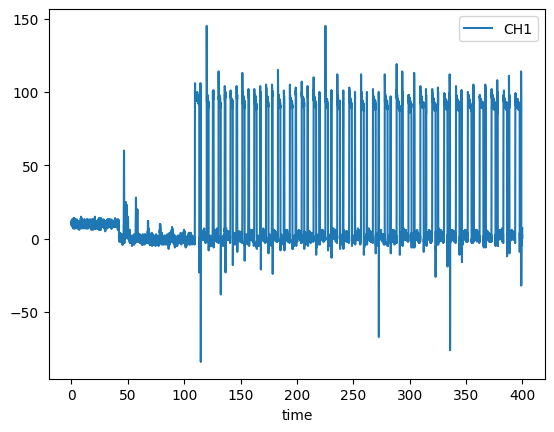

In [19]:
df.plot(x="time",y="CH1")

<Axes: xlabel='time'>

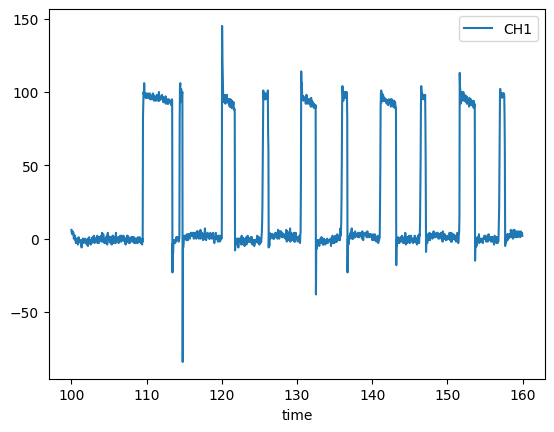

In [20]:
df.iloc[2500:4000].plot(x="time",y="CH1")

In [17]:
import matplotlib.pyplot as plt

109.5 114.4 204.08163265306098 khz
114.4 120.0 178.57142857142875 khz
120.0 125.5 181.8181818181818 khz


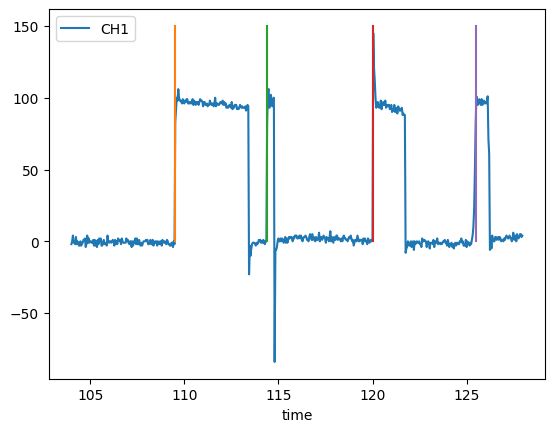

In [58]:
df.iloc[2600:3200].plot(x="time",y="CH1")
import numpy as np
t=np.zeros(100)
t[0]=109.5
t[1]=114.4
t[2]=120
t[3]=125.5
xold=None
for x in t:
    if x>0:
        plt.plot([x,x],[0,150])
for x in t:
    if x>0:
        try: 
            print( xold, x,1e3/(x-xold),"khz")
        except:xold=x
        xold=x


In [59]:
from utils import *

In [93]:
indx=trigger (sig =df.CH1, thresh= 50, transition= "fall", marginI = 20)
io=indx[0]
time=df.time.values
freq=[]
for i in indx[1:]:
    freq.append(1e3/(time[i]-time[io]))#, "kh")
    io=i
print("debut")
print(freq[:3])
print("fin")
print(freq[-3:])
#plt.plot(freq[:])

debut
[np.float64(14.997000599880023), np.float64(735.2941176470591), np.float64(143.67816091954006)]
fin
[np.float64(480.76923076923447), np.float64(109.64912280701749), np.float64(714.2857142857259)]


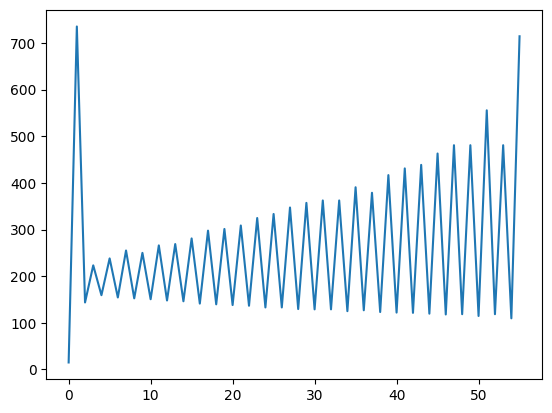

In [94]:
plt.plot(freq[:])

<Axes: xlabel='time'>

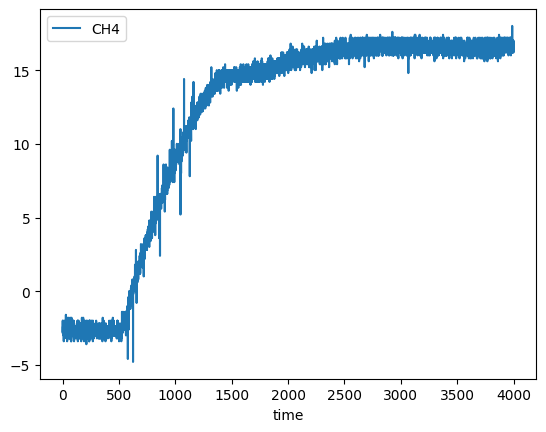

In [96]:
#2026-02-01_12-52-08-874.csv
df=pd.read_csv("2026-01-31_21-02-44-983.csv")
df.time=df.time*1e6
df.columns
df.plot(x="time", y= "CH4")

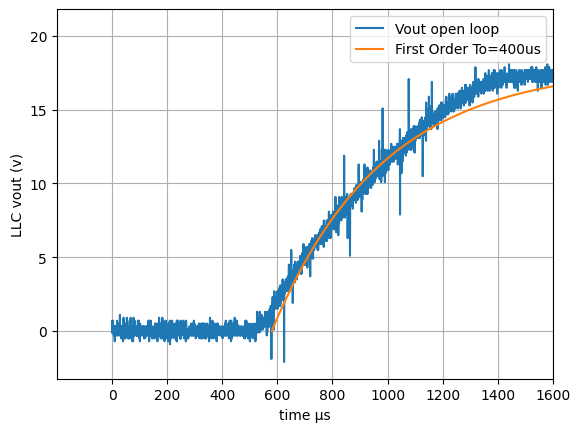

In [121]:
CH4=df.CH4.values
CH4 -=CH4[:200].mean()
plt.plot(df.time,CH4, label='Vout open loop')
plt.xlim([None, 1600])
t0=580
E=18
t=(df.time-t0)
t=t[t>=0]
TO= 200*2
v=E*(1-np.exp(-t/TO))
plt.plot(t+t0,v, label=f'First Order To={TO}us')
plt.legend()
plt.xlabel("time µs")
plt.ylabel("LLC vout (v)")
plt.grid()

<Axes: xlabel='time'>

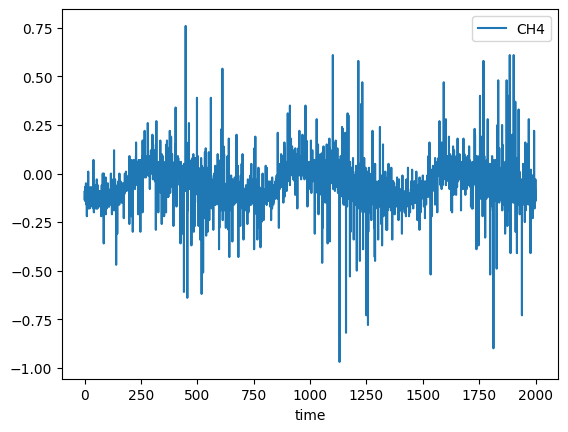

In [133]:
#2026-02-01_12-52-08-874.csv
#df=pd.read_csv("2026-02-01_12-52-08-874.csv")

df=pd.read_csv("2026-02-01_13-02-37-631.csv")
df.time=df.time*1e6
df.columns
df.plot(x="time", y= "CH4")

In [134]:
df.head()

,CH1,CH4,time,Ts
0,2.0,-0.13,0.0,2.000000e-07
1,2.0,-0.12,0.2,NaN
2,2.0,-0.09,0.4,NaN
3,1.0,-0.12,0.6,NaN
4,2.0,-0.11,0.8,NaN


In [135]:
len(time[indx][:len(freq[:])]), len(freq[:])

(241, 241)

debut
[np.float64(121.95121951219515), np.float64(119.04761904761902), np.float64(119.04761904761902)]
fin
[np.float64(128.20512820512522), np.float64(128.20512820677334), np.float64(124.99999999844036)]


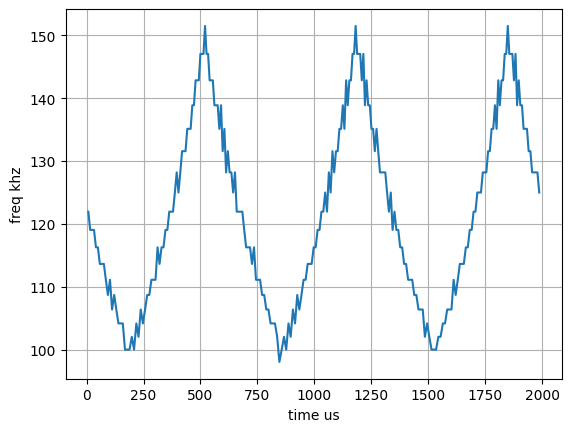

In [142]:
indx=trigger (sig =df.CH1, thresh=None, transition= "fall", marginI = 20)
io=indx[0]
time=df.time.values
freq=[]
for i in indx[1:]:
    freq.append(1e3/(time[i]-time[io]))#, "kh")
    io=i
print("debut")
print(freq[:3])
print("fin")
print(freq[-3:])
t=time[indx][:len(freq[:])]

plt.plot(t, freq[:])
plt.xlabel("time us")
plt.ylabel("freq khz")

#plt.plot(df.time, df.CH4.values)

plt.grid()

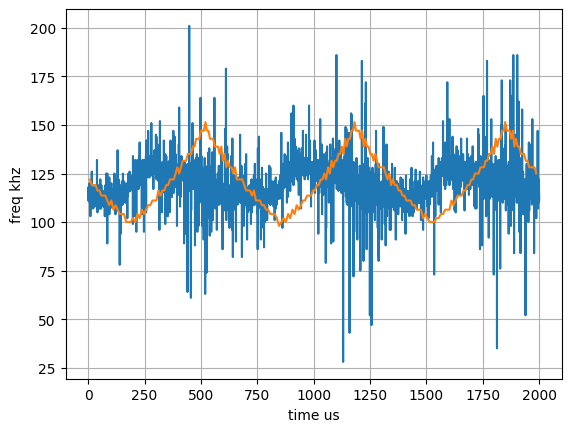

In [147]:

plt.xlabel("time us")
plt.ylabel("freq khz")

plt.plot(df.time, df.CH4.values*100+125)
plt.plot(t, freq[:])
plt.grid()

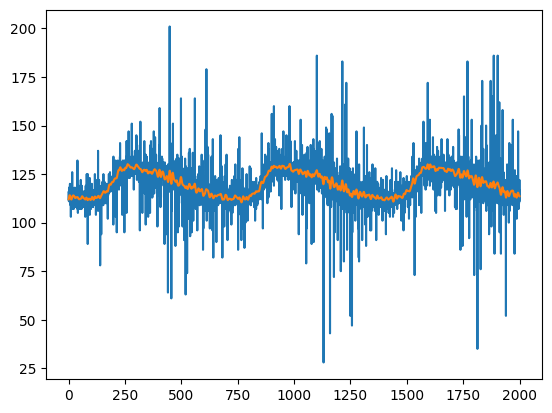

In [154]:
import numpy as np
from scipy.signal import butter, sosfiltfilt

fs =1/df.Ts.iloc[0]        # sampling frequency (20 MHz)
fc = 0.1e6         # cutoff frequency (1 MHz)
order = 4        # 4th order is usually enough

# Design filter in SOS form (important for stability)
sos = butter(order, fc, btype='low', fs=fs, output='sos')

x=df.CH4.values*100+125
# x = your signal (1D numpy array)
y = sosfiltfilt(sos, x)
plt.plot(df.time, x)
plt.plot(df.time, y)

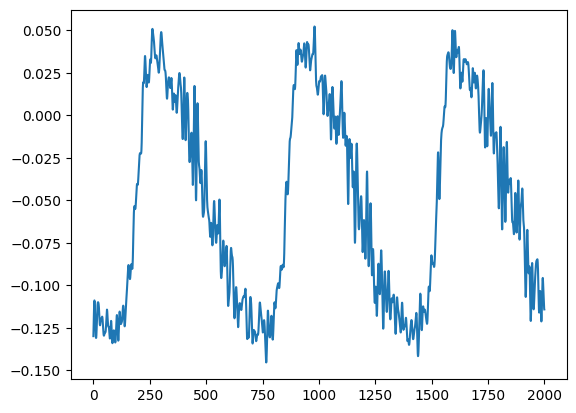

In [158]:
plt.plot(df.time, sosfiltfilt(sos, df.CH4.values))


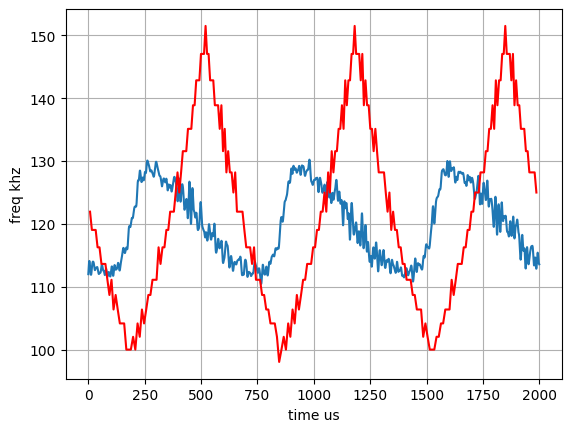

In [157]:

plt.xlabel("time us")
plt.ylabel("freq khz")

#plt.plot(df.time, x)
plt.plot(df.time, y)
plt.plot(t, freq[:], c="r")
plt.grid()